### 2-Point Ray Tracing

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [50.0, 100.0, 150.0]
 * Zero: [29.964822758816812, 69.92990081692221, 119.90563525707921]
 * Inf-norm of residuals: 0.000000
 * Iterations: 2
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 3
 * Jacobian Calls (df/dx): 3

 ray has the following fields: (:xk0, :xk, :t0, :t)

 Traveltimes:
Initial: 1.8192673235933188
Final:   1.8189547389860001



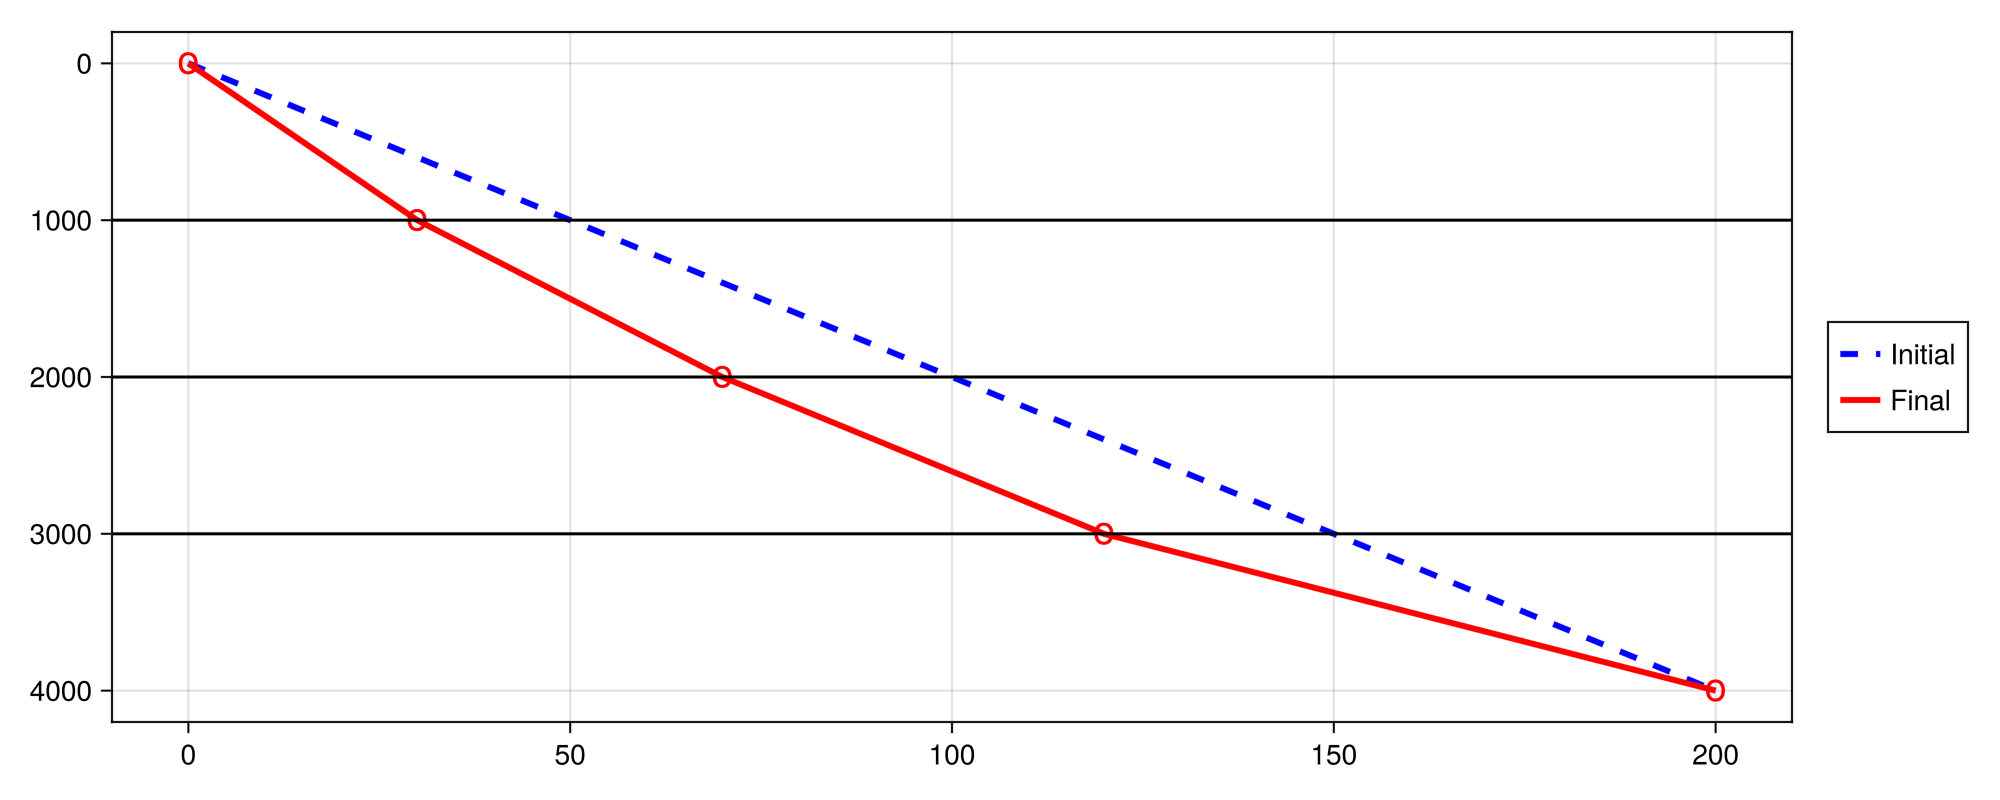

GLMakie.Screen(...)

In [ ]:
using SeisTimes
using GLMakie
Makie.inline!(true)

# define layer properties and interface depths
vp_layers = [1500, 2000, 2500, 4000];
vs_layers = [1000, 1500, 2000, 3000];
eps_layers = [0.2, 0.2, 0.2, 0.2]
del_layers = [-0.1, -0.1, -0.1, -0.1]
interface_depths = [1000, 2000, 3000];

# combine into nlayer x 4 matrix
M = hcat(vp_layers, vs_layers, eps_layers, del_layers)

phase = :P # :P, :S
src = (0, 0)
rcv = (200, 4000)

# run 2-point ray tracing 
ray = ray_bending(phase, M, interface_depths, src, rcv; verbose=true)
print("\n ray has the following fields: ", fieldnames(typeof(ray)), "\n")


# inital ray segments and travel time (straight connection)
xk0 = ray.xk0 
t0 = ray.t0 

# final ray segments and travel time 
xk = ray.xk
t = ray.t

println("Traveltimes: \n
Initial: $(t0) \n
Final:   $(t)  \n
")

# plot ray 
fig = Figure(size=(1000,400)) 
ax = Axis(fig[1,1], yreversed=true)

ini = lines!(ax, [x[1] for x in xk0], [x[2] for x in xk0], color=:blue, linestyle=:dash, overdraw=true, linewidth=3)
opt = lines!(ax, [x[1] for x in xk], [x[2] for x in xk], color=:red, overdraw=true,linewidth=3)

scatter!(ax,
    [x[1] for x in xk],
    [x[2] for x in xk],
    color = :red,
    markersize = 20,
    marker = 'o', overdraw=true
)

for z in interface_depths
    hlines!(ax,z,color=:black) 
end

Legend(fig[1,2], [ini, opt], ["Initial", "Final"])
display(fig)



### Traveltime Grids

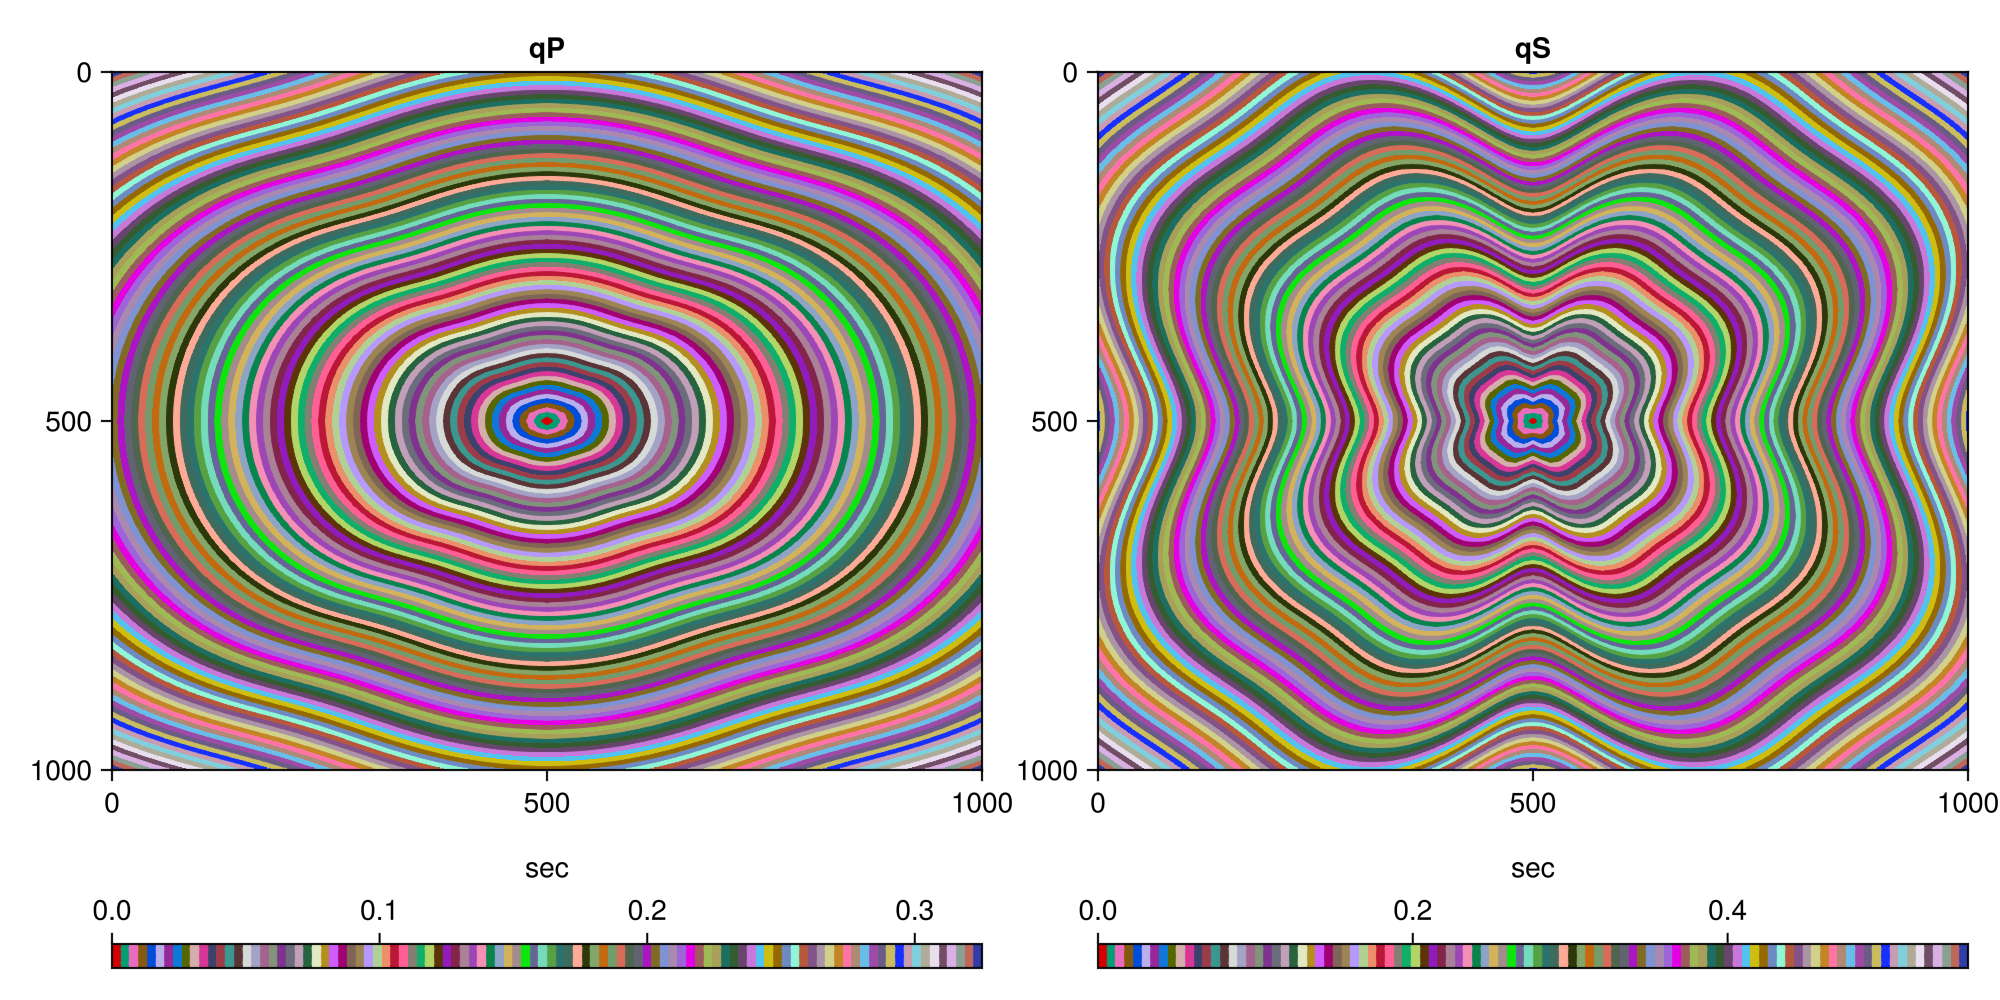

GLMakie.Screen(...)

In [40]:
# homogeneous medium
M = zeros(1,4)
M[1] = 2000 # vp 
M[2] = 1000 # vs 
M[3] = 0.25 # eps 
M[4] = -0.1 # del
interface_depths = []

# create grid 
h = 10 
x_coords = 0:h:1000 
z_coords = 0:h:1000
nx, nz = length(x_coords), length(z_coords)

# compute travel times 
tt_p = zeros(nx,nz)
tt_s = zeros(nx,nz)

src = (500, 500)
for x in 1:nx, z in 1:nz 
    rcv = (x_coords[x], z_coords[z])
    if src != rcv
        tt_p[x,z] = ray_bending(:P, M, interface_depths, src, rcv; verbose=false).t 
        tt_s[x,z] = ray_bending(:S, M, interface_depths, src, rcv; verbose=false).t
    end 
end 

# plot 
fig = Figure(size=(1000,500)) 
imgs = [tt_p, tt_s]
names = ["qP", "qS"]
for (i, img) in enumerate(imgs)
    ax = Axis(fig[1,i], title=names[i], yreversed=true)
    im = contourf!(ax, x_coords, z_coords, img, levels=100, colormap=:glasbey_bw_minc_20_n256)
    Colorbar(fig[2,i], im, vertical=false, label="sec")
end
display(fig)
